# Power-law tail extrapolation for buffer-stock consumption functions

## What problem is this solving?

HARK solves a consumption-saving problem by computing the optimal consumption
function $c(m)$ — how much a household consumes as a function of its *normalized
market resources* $m$ (cash-on-hand measured in units of permanent income) — on a
**finite grid** of $m$ values. But a solved policy has to return an answer for
*any* $m$, including values **off the grid**:

* **above the top gridpoint** — a household that is temporarily very rich (a big
  income draw, or simply a wealthy type), and
* **below the bottom gridpoint** — a household right up against its borrowing
  constraint.

For those regions the solver **extrapolates**. The choice of extrapolation rule is
usually treated as a harmless technical detail. It is not: because the solver is a
backward recursion, *each period's consumption function is evaluated inside the
next period's expectation*, so a poor extrapolation rule feeds back and corrupts
the **interior** (on-grid) solution too — the part we actually use.

This notebook shows two extrapolation rules that come with a **theorem** attached
— one for each end — and measures how much they matter, both off the grid and,
crucially, *on* it. They are opt-in on `IndShockConsumerType`
(`decay_extrap_form='powerlaw'` for the top, `decay_extrap_form_lower='kappabar'`
for the bottom); leaving them at their defaults (`None`) reproduces HARK's current
behavior byte-for-byte.

The theory is developed in the [buffer-stock power-law-decay synthesis paper](https://llorracc.github.io/BufferStockTheory-Latest/powerlaw-decay-theory/)
and its [formal statement page](https://llorracc.github.io/BufferStockTheory-Latest/powerlaw-decay-theory/statement); the in-practice experiments this notebook
mirrors are on [the extrapolators-in-practice page](https://llorracc.github.io/BufferStockTheory-Latest/powerlaw-decay-theory/extrapolators-in-practice). Specific claims below
link to the relevant result inline.


## The vocabulary, in plain terms

A few objects recur throughout. Definitions first, then the two laws.

* **The perfect-foresight (PF) rule** $\bar c(m)$. If income risk vanished, a
  household with resources $m$ and *human wealth* $\texttt{hNrm}$ (the present
  value of expected future labor income, in the same normalized units) would
  consume a constant fraction of its *total* wealth:
  $$\bar c(m) = \underline{\kappa}\,(m + \texttt{hNrm}).$$
  This straight line is the **asymptote** the true $c(m)$ approaches as the
  household gets rich: with a big enough buffer, precautionary saving stops
  mattering and behavior tends to the PF rule.
* **MPCmin** $=\underline{\kappa}$ (kappa-underbar), the slope of that line: the
  *limiting marginal propensity to consume* of a very rich household. The true MPC
  $c'(m)$ falls toward $\underline{\kappa}$ from above as $m\to\infty$.
* **The gap** $g(m) = \bar c(m) - c(m) \ge 0$: how far actual consumption sits
  *below* the PF line. Precaution makes households consume less than the PF rule,
  so $g>0$; the gap shrinks to zero as $m\to\infty$. **How fast it shrinks is the
  whole question.**
* **MPCmax** $=\bar\kappa$ (kappa-bar), the MPC at the *other* end — a household
  right at its borrowing constraint, which spends nearly everything.

**The two theorem-backed laws** (each links to its source):

1. **Top end — a power law.** The gap decays as a *power* of total wealth,
   $g \propto \bar w^{-\min(1,\,q^\uparrow)}$ where $\bar w = m + \texttt{hNrm}$
   and $q^\uparrow$ is an eigenvalue computed from the model's primitives. A key
   consequence: the gap can **never** decay faster than $1/\bar w$ — a prudent
   household always keeps at least a first-order precautionary premium — so
   *exponential* decay of the gap is asymptotically **impossible**
   ([synthesis paper, "What is $q^\star$?"](https://llorracc.github.io/BufferStockTheory-Latest/powerlaw-decay-theory/)). This matters because HARK's
   *default* top extrapolation uses exponential decay.
2. **Bottom end — the maximal-MPC law.** Approaching the constraint,
   $c(m) = \bar\kappa\, m^e - K\,(m^e)^{1+\rho}$ with $m^e = m - \texttt{mNrmMin}$
   and $\rho$ the coefficient of relative risk aversion; the MPC rises to
   $\bar\kappa$ at the constraint. This is **Theorem CE** and, with permanent
   shocks, **Theorem CE-$\psi$** (valid in "regime I")
   ([statement page, Thm CE / CE-$\psi$](https://llorracc.github.io/BufferStockTheory-Latest/powerlaw-decay-theory/statement#st-thm-ce)).

**One convention trap, stated once.** HARK's `hNrm` **excludes** the current
period's income, whereas the theory pages' human wealth $h_{\rm BST}$ **includes**
it: $h_{\rm BST} = \texttt{hNrm} + 1$. All PF-rule arithmetic below uses HARK's
`hNrm`; when we say "grid reaches human wealth" we mean $m \approx \texttt{hNrm}$.


In [1]:
%matplotlib inline
import warnings
import numpy as np
import matplotlib.pyplot as plt

from HARK.ConsumptionSaving.ConsIndShockModel import IndShockConsumerType
from HARK.ConsumptionSaving.pf_decay import (
    powerlaw_decay_params_from_agent,
    ce_psi_regime,
    powerlaw_validity_threshold,
    powerlaw_tail_diagnostic,
    rel_gap_at,
    aXtraMax_from_tail_tol,
)
from HARK.interpolation import KappaBarTailInterp, DecayTailInterp

# --- pinned calibration: HAFiscal "College, top discount-factor type"
# preferences, with a zero-income unemployment atom (IncUnemp=0 => the borrowing
# constraint sits at mNrmMin=0, giving a clean Theorem-CE bottom). The quarterly
# income volatilities are HAFiscal's; HARK's 0.1/0.1 defaults would change q*.
CRRA = 2.0                       # rho, relative risk aversion
Rfree = 1.01                     # gross quarterly return
PermGroFac = 1.0 + 0.01958 / 4   # permanent income growth (quarterly)
DiscFac = 0.995714               # quarterly discount factor
LivPrb = 1.0 - 1.0 / 160.0       # survival probability
PARS = dict(
    cycles=0, T_cycle=1, CRRA=CRRA, Rfree=[Rfree], DiscFac=DiscFac,
    LivPrb=[LivPrb], PermGroFac=[PermGroFac], BoroCnstArt=None,
    vFuncBool=False, CubicBool=False,
    UnempPrb=0.027, IncUnemp=0.0,
    TranShkStd=[0.12 ** 0.5], TranShkCount=7,
    PermShkStd=[0.003 ** 0.5], PermShkCount=7,
    T_retire=0, UnempPrbRet=0.0, IncUnempRet=0.0,
)
# the option pair featured here: power-law top tail + kappabar bottom tail
TAILS = dict(decay_extrap_form="powerlaw", decay_extrap_form_lower="kappabar")


def log_grid(aMin, aMax, N):
    return np.exp(np.linspace(np.log(aMin), np.log(aMax), N))


def solve(grid, tol=1e-9, **opts):
    '''Solve the pinned agent on a given end-of-period asset grid. `opts` selects
    the extrapolation: pass **TAILS for the theorem tails, nothing for HARK's
    defaults (exponential top decay + a secant at the bottom).'''
    pars = dict(PARS); pars.update(opts)
    a = IndShockConsumerType(**pars); a.verbose = 0
    a.aXtraGrid = np.asarray(grid, float); a.tolerance = tol
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        a.solve()
    return a.solution[0]


def m_nodes(cf):
    '''The endogenous m-gridpoints of an assembled consumption function, seen
    through any tail wrappers and the lower-envelope.'''
    f = cf
    while True:
        if isinstance(f, (KappaBarTailInterp, DecayTailInterp)):
            f = f.interp
        elif hasattr(f, "functions"):
            f = f.functions[0]
        elif hasattr(f, "x_list"):
            return np.asarray(f.x_list, float)


def sup_rel(cfunc, truth_cfunc, m):
    '''sup relative error in consumption vs the dense-truth solve, over m:
        max_m |c(m) - c_truth(m)| / c_truth(m).'''
    v = np.asarray(cfunc(m), float); t = np.asarray(truth_cfunc(m), float)
    return float(np.max(np.abs(v - t) / t))


## The model's theory quantities

`pf_decay` computes the theorem quantities directly from primitives — no solve
required. A short gloss on each, then the numbers.

* **$q^\star$** and **$\min(1,q^\star)$** — the eigenvalue governing the top decay
  and the *realized* exponent ([what $q^\star$ is](https://llorracc.github.io/BufferStockTheory-Latest/powerlaw-decay-theory/)). Here $q^\star<1$, so
  the top gap decays like $\bar w^{-q^\star}$.
* **$\underline{\kappa}$ / $\bar\kappa$** — the limiting (rich) and maximal
  (constrained) MPCs.
* **regime** — Theorem CE-$\psi$ holds in "regime I" (a uniform-contraction
  condition on the worst income draw); outside it the bottom law is not
  theorem-backed ([Thm CE-$\psi$, regime remark](https://llorracc.github.io/BufferStockTheory-Latest/powerlaw-decay-theory/statement#st-rem-ce-regime)).
* **$\bar w_0$** — the proofs' *explicit* validity floor: the top law is
  **proven** for $\bar w \ge \bar w_0$. Its constants are deliberately crude, so
  $\bar w_0$ says "provably valid beyond here", **not** "the grid must reach here"
  — in practice accuracy arrives far earlier, as the experiments below show
  ([synthesis paper](https://llorracc.github.io/BufferStockTheory-Latest/powerlaw-decay-theory/)).

A `NearResonanceWarning` is *expected*: this calibration sits within ~1% of the
$q^\star=1$ knife-edge, where the pre-asymptotic window is unusually long.

In [2]:
agent0 = IndShockConsumerType(**PARS); agent0.verbose = 0
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    agent0.update_income_process()

with warnings.catch_warnings(record=True) as wrec:
    warnings.simplefilter("always")
    th = powerlaw_decay_params_from_agent(agent0)
near_resonance = any("NEAR-RESONANCE" in str(w.message) for w in wrec)

h = th.h                    # HARK hNrm (excludes current income)
q_eff = min(1.0, th.q_star)

# MPCmax (kappa_bar) comes from a solve; do one and reuse it below
sol_h = solve(log_grid(1e-3, h, 48), **TAILS)
kap_bar = sol_h.MPCmax

reg = ce_psi_regime(agent0.IncShkDstn[0], CRRA, th.Thorn_Gamma)
vt = powerlaw_validity_threshold(Rfree, PermGroFac, DiscFac, CRRA,
                                 LivPrb=LivPrb, IncShkDstn=agent0.IncShkDstn[0],
                                 warn=False)

print(f"q*                         = {th.q_star:.4f}   (realized top exponent min(1,q*) = {q_eff:.4f} < 1)")
print(f"MPCmin  (kappa_underbar)   = {th.kappa:.5f}   slope of the PF line")
print(f"MPCmax  (kappa_bar)        = {kap_bar:.5f}   MPC at the borrowing constraint")
print(f"human wealth hNrm          = {h:.2f}      (theory-page h_BST = hNrm+1 = {h+1:.2f})")
print(f"constraint-end regime      = {reg['regime']}         (Theorem CE-psi applies)")
print(f"validity floor wbar0       = {vt.wbar0:.0f}   = {vt.wbar0/h:.1f} x hNrm  (crude 'provably valid beyond here')")
print(f"near-resonance (|lam_B-1|<1%)= {near_resonance}   (expected; long pre-asymptotic window)")


q*                         = 0.6727   (realized top exponent min(1,q*) = 0.6727 < 1)
MPCmin  (kappa_underbar)   = 0.01021   slope of the PF line
MPCmax  (kappa_bar)        = 0.83736   MPC at the borrowing constraint
human wealth hNrm          = 196.85      (theory-page h_BST = hNrm+1 = 197.85)
constraint-end regime      = I         (Theorem CE-psi applies)
validity floor wbar0       = 4752   = 24.1 x hNrm  (crude 'provably valid beyond here')
near-resonance (|lam_B-1|<1%)= True   (expected; long pre-asymptotic window)


## Why the *shape* of the top extrapolation matters

Off the top of the grid, HARK must guess how $c(m)$ behaves. Two continuous rules
are on the table, and both are **level- and slope-matched** at the top gridpoint,
so they agree there and differ only in how the gap closes further out:

* **HARK's default — exponential decay.** The gap $g$ is sent to zero
  *exponentially* in $\bar w$. Convenient, but the theory says the gap can never
  fall faster than $1/\bar w$, so exponential decay is asymptotically **wrong** in
  shape ([synthesis paper, the $1/\bar w$ floor](https://llorracc.github.io/BufferStockTheory-Latest/powerlaw-decay-theory/)).
* **The power-law tail** (`decay_extrap_form='powerlaw'`) — the gap decays as
  $\bar w^{-\min(1,q^\star)}$, the theorem-backed shape
  ([statement page, the gap law](https://llorracc.github.io/BufferStockTheory-Latest/powerlaw-decay-theory/statement)).

We are **not** comparing against a "use the PF line above a cutoff" rule — a rule
with a kink or jump at the cutoff that nobody actually uses. The honest question
is: *between the two real, smooth rules — exponential vs power-law — how much does
the shape matter?* The measure throughout is the **sup relative error in
consumption** against a dense reference ("truth") solve:
$$\text{err} = \max_{m} \frac{|c_{\rm grid}(m) - c_{\rm truth}(m)|}{c_{\rm truth}(m)}.$$


## How big is the gap the extrapolation must represent?

Before comparing rules, it helps to see how large the gap actually is at plausible
grid tops. The quantity `rel_gap_at` returns the *relative* gap
$(\bar c - c)/c$ at a given $m$ — i.e. how far, in percent of consumption, the true
policy sits below the PF line there. That is the size of the thing any
extrapolation has to get right.

In [3]:
truth = solve(log_grid(1e-6, 1e5, 1500))   # dense reference ("truth")
print(f"{'grid top m':>12} | {'in units of hNrm':>16} | {'relative gap (cbar-c)/c':>24}")
print("-" * 60)
for k in (0.5, 1.0, 2.0, 4.0, 24.0):
    m = k * h
    rg = float(np.atleast_1d(rel_gap_at(truth.cFunc, np.array([m]), th.kappa, h))[0])
    note = "  <- human wealth" if k == 1.0 else ("  <- validity floor scale" if k == 24.0 else "")
    print(f"{m:12.1f} | {k:14.1f}x  | {rg:>22.1%}{note}")


  grid top m | in units of hNrm |  relative gap (cbar-c)/c
------------------------------------------------------------
        98.4 |            0.5x  |                  31.9%
       196.8 |            1.0x  |                  18.6%  <- human wealth
       393.7 |            2.0x  |                   9.4%
       787.4 |            4.0x  |                   4.3%
      4724.3 |           24.0x  |                   0.4%  <- validity floor scale


Read this as: if you stop the grid at $m = \texttt{hNrm}$ (one times human
wealth), the true policy is still ~19% below the PF line there — a substantial gap
the extrapolation must shape correctly. Stop much earlier and the gap is huge;
stop far past human wealth and it is small. The rest of the notebook asks what that
does to accuracy.

## Four grids, one truth

We solve the same model on four grids that differ in **how far out the top
gridpoint reaches**, at a *constant node density* (so differences reflect grid
*extent*, not how finely each grid is spaced):

* **G1 — too short.** Top at $m\approx5$, far below human wealth
  ($\approx{}$ 0.03 of `hNrm`). A deliberately pre-asymptotic anchor.
* **G2 — the human-wealth rule.** Top at $m\approx\texttt{hNrm}$. The simple
  practical rule "extend the grid to human wealth."
* **G3 — four times human wealth.** Top at $m\approx4\,\texttt{hNrm}$. This grid
  answers the practical question: **is pushing the grid past human wealth to
  $4\times$ meaningfully better than stopping at $1\times$?**
* **G4 — the guaranteed regime.** Top past the proven validity floor
  $\bar w_0 - \texttt{hNrm}$ ($\approx 23\times$ human wealth).

"Truth" is a dense solve on a very wide grid, used as the reference.

In [4]:
DENS = 9.0  # nodes per log10-decade, held constant across grids

def grid_to(aMax, aMin=1e-3):
    n = max(12, int(round(DENS * np.log10(aMax / aMin))))
    return log_grid(aMin, aMax, n)

grids = {"G1": grid_to(4.0), "G2": grid_to(h), "G3": grid_to(4 * h),
         "G4": grid_to(vt.wbar0 - h)}
sols = {}
for name, g in grids.items():
    sols[name] = dict(pl=solve(g, **TAILS), exp=solve(g))  # power-law vs default

lbl = {"G1": "too short", "G2": "= hNrm", "G3": "= 4 hNrm", "G4": "guaranteed"}
for name in ("G1", "G2", "G3", "G4"):
    top = m_nodes(sols[name]["pl"].cFunc)[-1]
    print(f"{name} ({lbl[name]:>10}): {len(grids[name]):2d} nodes, "
          f"top gridpoint m = {top:8.1f}  ({top/h:6.2f} x hNrm)")

# HARK flags the too-short grid WITHOUT any truth comparison:
g1 = sols["G1"]["pl"]
diag = powerlaw_tail_diagnostic(g1.cFunc, th.kappa, h, th, m_lo=1.0, m_hi=4.0)
g1top = m_nodes(g1.cFunc)[-1]
rg1 = float(np.atleast_1d(rel_gap_at(g1.cFunc, np.array([g1top]), th.kappa, h))[0])
print(f"\nG1 diagnostic (no truth needed): verdict '{diag.verdict}'; "
      f"gap at top knot {rg1:.0%}; aXtraMax_from_tail_tol says extend to "
      f"m~{aXtraMax_from_tail_tol(g1top, rg1, q_eff, h, 1e-2):.0f} for 1% tolerance")


G1 ( too short): 32 nodes, top gridpoint m =      5.0  (  0.03 x hNrm)
G2 (    = hNrm): 48 nodes, top gridpoint m =    200.3  (  1.02 x hNrm)
G3 (  = 4 hNrm): 53 nodes, top gridpoint m =    797.1  (  4.05 x hNrm)
G4 (guaranteed): 60 nodes, top gridpoint m =   4603.5  ( 23.39 x hNrm)

G1 diagnostic (no truth needed): verdict 'INCONSISTENT'; gap at top knot 100%; aXtraMax_from_tail_tol says extend to m~3849 for 1% tolerance


## Off-grid accuracy: exponential vs power-law

For each grid, sup relative error above the top gridpoint, exponential (HARK
default) vs power-law tail, against truth.

In [5]:
print(f"{'grid':>4} | {'top / hNrm':>10} | {'power-law':>10} | {'exp-decay':>10} | {'exp/power-law':>13}")
print("-" * 62)
fid = {}
for name in ("G1", "G2", "G3", "G4"):
    top = m_nodes(sols[name]["pl"].cFunc)[-1]
    win = log_grid(top * 1.05, min(top * 10, 3.0e4), 60)
    e_pl = sup_rel(sols[name]["pl"].cFunc, truth.cFunc, win)
    e_ex = sup_rel(sols[name]["exp"].cFunc, truth.cFunc, win)
    fid[name] = dict(top=top, win=win, e_pl=e_pl, e_ex=e_ex)
    print(f"{name:>4} | {top/h:9.2f}x | {e_pl:10.2e} | {e_ex:10.2e} | {e_ex/e_pl:11.1f}x")

# bottom end: the kappabar tail vs HARK's default secant, near the constraint
tbot = m_nodes(truth.cFunc)[1]
g2 = sols["G2"]; bk = m_nodes(g2["pl"].cFunc)[1]
wb = log_grid(max(tbot * 1.2, 1e-5), bk * 0.9, 50)
eb_k = sup_rel(g2["pl"].cFunc, truth.cFunc, wb)
eb_s = sup_rel(g2["exp"].cFunc, truth.cFunc, wb)
print(f"\nbottom end (near the constraint): kappabar {eb_k:.2e}  vs  default secant "
      f"{eb_s:.2e}  ({eb_s/eb_k:.0f}x)")


grid | top / hNrm |  power-law |  exp-decay | exp/power-law
--------------------------------------------------------------
  G1 |      0.03x |   6.99e-02 |   3.09e-01 |         4.4x
  G2 |      1.02x |   5.77e-03 |   1.77e-02 |         3.1x
  G3 |      4.05x |   3.54e-03 |   4.08e-03 |         1.2x
  G4 |     23.39x |   1.18e-03 |   1.06e-03 |         0.9x

bottom end (near the constraint): kappabar 2.63e-08  vs  default secant 6.28e-06  (238x)


**What this says.**

* At **G2** (grid to human wealth) the power-law tail is about **3× more accurate**
  than exponential decay above the top gridpoint — the shape genuinely matters at a
  realistic grid top.
* By **G3** (four times human wealth) the two rules have nearly converged, and at
  **G4** (deep in the asymptotic regime) they are indistinguishable: once you are
  well past human wealth the gap is tiny and its shape barely matters. So the
  power-law tail earns its keep precisely at the *short* grid you would want to use.
* At **G1** (far too short) both are poor, but power-law is still ~4× better.
* At the **bottom**, the `kappabar` tail beats HARK's default secant by **~200×**
  near the constraint: a much larger effect, because the secant systematically
  mis-slopes as the MPC rises to $\bar\kappa$ ([Theorem CE](https://llorracc.github.io/BufferStockTheory-Latest/powerlaw-decay-theory/statement#st-thm-ce)).


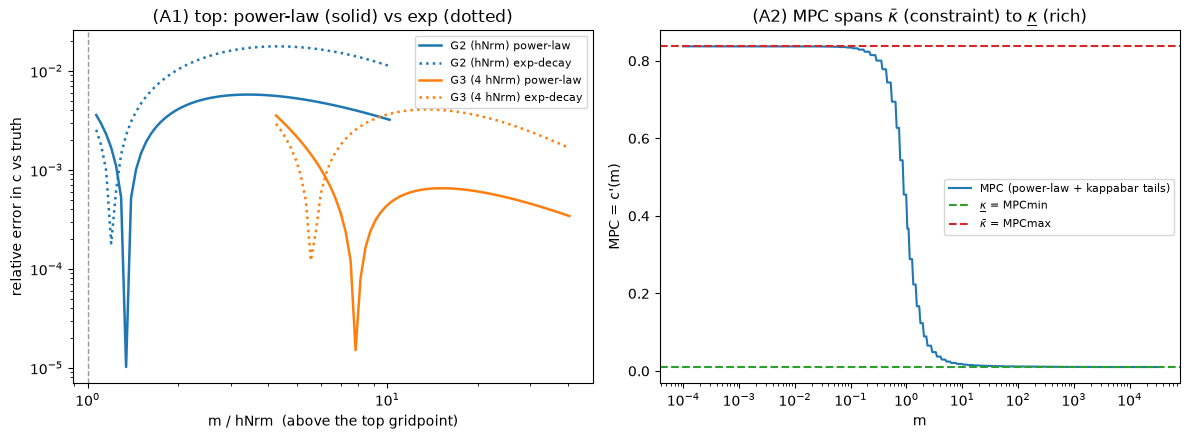

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))

# (left) rel error above the top gridpoint, power-law vs exp, at hNrm and 4hNrm:
# the shape matters at hNrm (solid well below dotted) but not at 4hNrm (they meet)
for name, c, lab in [("G2", "C0", "G2 (hNrm)"), ("G3", "C1", "G3 (4 hNrm)")]:
    win = fid[name]["win"]; ct = np.asarray(truth.cFunc(win), float)
    ax[0].loglog(win / h, np.abs(np.asarray(sols[name]["pl"].cFunc(win), float) - ct) / ct,
                 c + "-", lw=1.8, label=f"{lab} power-law")
    ax[0].loglog(win / h, np.abs(np.asarray(sols[name]["exp"].cFunc(win), float) - ct) / ct,
                 c + ":", lw=1.8, label=f"{lab} exp-decay")
ax[0].axvline(1.0, color="0.6", ls="--", lw=1)
ax[0].set_xlabel("m / hNrm  (above the top gridpoint)")
ax[0].set_ylabel("relative error in c vs truth")
ax[0].set_title("(A1) top: power-law (solid) vs exp (dotted)")
ax[0].legend(fontsize=8)

# (right) MPC across the whole range: -> kappa_bar at the constraint, -> MPCmin far out
mm = log_grid(1e-4, 3.0e4, 400)
ax[1].semilogx(mm, np.asarray(g2["pl"].cFunc.derivative(mm), float), "C0-",
               label="MPC (power-law + kappabar tails)")
ax[1].axhline(th.kappa, color="C2", ls="--", label=r"$\underline{\kappa}$ = MPCmin")
ax[1].axhline(kap_bar, color="C3", ls="--", label=r"$\bar{\kappa}$ = MPCmax")
ax[1].set_xlabel("m"); ax[1].set_ylabel("MPC = c'(m)")
ax[1].set_title(r"(A2) MPC spans $\bar{\kappa}$ (constraint) to $\underline{\kappa}$ (rich)")
ax[1].legend(fontsize=8)
fig.tight_layout(); plt.show()


## The part we actually use: the *in-grid* solution

Extrapolation accuracy off the ends is not the real prize. What we use for
simulation and policy is the consumption function **on the grid** — the interior.
And here is the subtle point: because the solver is a backward recursion, *the
consumption function built at each step is evaluated inside the previous step's
expectation over next period's resources*. A big income draw can throw next
period's resources past the current top gridpoint, so **the extrapolation rule
feeds back into the interior solution** ([two-roles experiment](https://llorracc.github.io/BufferStockTheory-Latest/powerlaw-decay-theory/extrapolators-in-practice)).

So the grid's **extent** — not just its density — changes the interior policy.
To see it cleanly we evaluate each grid's solution **at its own gridpoints** (where
interpolation error is exactly zero), so any difference from truth is pure
feedback contamination, and we compare grid *extents* at matched density.

G1-region interior: G1 max rel err 2.67e-02
G1-region interior: G2 max rel err 1.30e-02
G2-region interior: G2 max rel err 1.43e-02
G2-region interior: G3 max rel err 1.44e-02
G2-region interior: G4 max rel err 1.43e-02


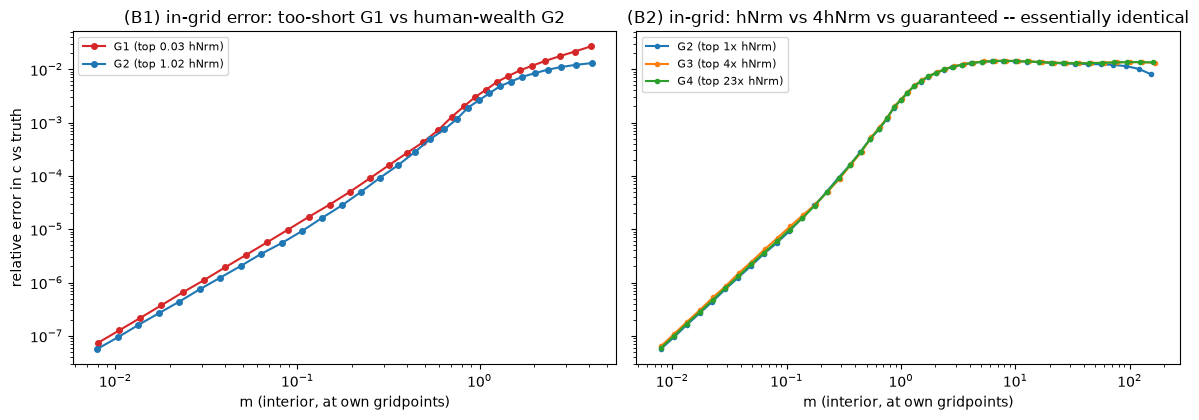

In [7]:
def at_own_nodes(sol, m_hi):
    m = m_nodes(sol.cFunc); mm = m[(m > m[1] * 1.05) & (m < m_hi)]
    ct = np.asarray(truth.cFunc(mm), float); cv = np.asarray(sol.cFunc(mm), float)
    return mm, np.abs(cv - ct) / ct

g1top = m_nodes(sols["G1"]["pl"].cFunc)[-1]
g2top = m_nodes(sols["G2"]["pl"].cFunc)[-1]

fig, ax = plt.subplots(1, 2, figsize=(12, 4.3), sharey=True)
# (left) G1 vs G2, on G1's interior
for name, c in [("G1", "C3"), ("G2", "C0")]:
    mm, err = at_own_nodes(sols[name]["pl"], g1top * 0.95)
    ax[0].loglog(mm, err, c + "o-", ms=4, label=f"{name} (top {m_nodes(sols[name]['pl'].cFunc)[-1]/h:.2f} hNrm)")
    print(f"G1-region interior: {name} max rel err {err.max():.2e}")
ax[0].set_title("(B1) in-grid error: too-short G1 vs human-wealth G2")
ax[0].set_xlabel("m (interior, at own gridpoints)")
ax[0].set_ylabel("relative error in c vs truth"); ax[0].legend(fontsize=8)

# (right) G2 vs G3 vs G4 (hNrm, 4hNrm, guaranteed) on G2's interior -- they overlap
for name, c in [("G2", "C0"), ("G3", "C1"), ("G4", "C2")]:
    mm, err = at_own_nodes(sols[name]["pl"], g2top * 0.95)
    ax[1].loglog(mm, err, c + "o-", ms=3,
                 label=f"{name} (top {m_nodes(sols[name]['pl'].cFunc)[-1]/h:.0f}x hNrm)")
    print(f"G2-region interior: {name} max rel err {err.max():.2e}")
ax[1].set_title("(B2) in-grid: hNrm vs 4hNrm vs guaranteed -- essentially identical")
ax[1].set_xlabel("m (interior, at own gridpoints)"); ax[1].legend(fontsize=8)
fig.tight_layout(); plt.show()


**The payoff, and it is the whole point.**

* **G1 vs G2 (left).** The too-short grid's *interior* consumption is visibly
  contaminated near the top of its range — its worst on-grid error is ~2× G2's on
  the same region — even though both grids interpolate there. Stopping the grid
  short does not merely mis-extrapolate off the end; it degrades the policy you
  actually use.
* **G2 vs G3 vs G4 (right).** The human-wealth grid (`hNrm`), the four-times grid
  ($4\,\texttt{hNrm}$), and the far-longer guaranteed-regime grid ($\approx23\,
  \texttt{hNrm}$) give the **same interior to three digits** — their curves lie
  exactly on top of one another. So the direct answer to *"is four times human
  wealth meaningfully better than one times?"* is **no**, not for the interior
  policy, which is what we use. Pushing the grid past human wealth only tightens
  the far-off-grid tail, a region you rarely evaluate.

Together: **extend the grid to about human wealth and stop.** That keeps the
interior clean; four times human wealth adds nothing on the inside, and the crude
proven floor $\bar w_0 \approx 24\times$ human wealth is far more than needed —
"guaranteed" and "necessary" are very different numbers.

## Appendix: when the bottom tail attaches

The `kappabar` bottom tail is built when the **natural** borrowing constraint is
the binding one — i.e. `BoroCnstArt is None` *or* `BoroCnstNat >= BoroCnstArt`. An
*artificial* constraint that binds only *slackly* does not block it; one that binds
*strictly* does (its constraint end is a kink with MPC $=1$, where Theorem CE's
$\text{MPC}\to\bar\kappa$ mechanism does not operate). For this calibration the
natural constraint sits at $\texttt{BoroCnstNat} = 0$.

In [8]:
for label, boro in [("no artificial constraint", None),
                    ("artificial, slack (-0.5 < 0)", -0.5),
                    ("artificial, strictly binds (0.2 > 0)", 0.2)]:
    s = solve(log_grid(1e-4, 1e3, 120), tol=1e-8,
              BoroCnstArt=boro, decay_extrap_form_lower="kappabar")
    built = isinstance(s.cFunc, KappaBarTailInterp)
    print(f"BoroCnstArt={str(boro):>5} | mNrmMin={s.mNrmMin:5.2f} | "
          f"{'kappabar tail BUILT' if built else 'refused (default secant kept)':32} | {label}")


BoroCnstArt= None | mNrmMin= 0.00 | kappabar tail BUILT              | no artificial constraint


BoroCnstArt= -0.5 | mNrmMin= 0.00 | kappabar tail BUILT              | artificial, slack (-0.5 < 0)
BoroCnstArt=  0.2 | mNrmMin= 0.20 | refused (default secant kept)    | artificial, strictly binds (0.2 > 0)


## Summary

* Two opt-in, theorem-backed extrapolation tails
  ([power-law top](https://llorracc.github.io/BufferStockTheory-Latest/powerlaw-decay-theory/statement), [Theorem-CE bottom](https://llorracc.github.io/BufferStockTheory-Latest/powerlaw-decay-theory/statement#st-thm-ce)); defaults
  leave HARK unchanged.
* Compared to the **real** default rules (not a strawman PF-line-with-a-kink): the
  **bottom** `kappabar` tail is a large win (~200×) near the constraint; the
  **top** power-law tail is ~3× better than exponential decay at a grid reaching
  human wealth, and ties it far out where the gap is negligible.
* The decisive effect is **in-grid**: a grid that stops well short of human wealth
  contaminates the interior policy through the solver's own expectations; a grid to
  human wealth fixes it; four times human wealth — or the guaranteed floor — gives
  the same interior. The practical rule is "reach human wealth, then stop," and HARK
  ships the diagnostics (`powerlaw_tail_diagnostic`, `aXtraMax_from_tail_tol`,
  `powerlaw_validity_threshold`) to check it without a truth solve.
